In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.9,
})

In [2]:
file_path='/fs/ess/PAS1475/yzhong/sf_project/scripts/CosMx_Lung_noise_benchmark/g2pm_dir/05_19_26'

In [3]:
node_feat_shuffle=torch.load(file_path+\
                             '/corpus_full_317M_05_19_wl_8_node_feat_shuffle_LP_model_niche/step_150000_linear_probe_node_spaGFM_f1_macro_stat.pt',
                             weights_only=False)

In [4]:
node_shift=torch.load(file_path+\
                      '/corpus_full_317M_05_19_wl_8_node_shift_LP_model_niche/step_150000_linear_probe_node_spaGFM_f1_macro_stat.pt',
                      weights_only=False)

In [5]:
segmentation_noise=torch.load(file_path+\
                             '/corpus_full_317M_05_19_wl_8_segmentation_noise_LP_model_niche/step_150000_linear_probe_node_spaGFM_f1_macro_stat.pt',
                             weights_only=False)

In [6]:
def extract_noise_level(x):
    x['sample']=[x.split('_')[0] for x in x.index.values]
    x['noise_level']=[x.split('_')[-1] for x in x.index.values]
    return x

node_feat_shuffle_df=pd.DataFrame(node_feat_shuffle).transpose()
node_shift_df=pd.DataFrame(node_shift).transpose()
segmentation_noise_df=pd.DataFrame(segmentation_noise).transpose()

node_feat_shuffle_df=extract_noise_level(node_feat_shuffle_df)
node_shift_df=extract_noise_level(node_shift_df)
segmentation_noise_df=extract_noise_level(segmentation_noise_df)

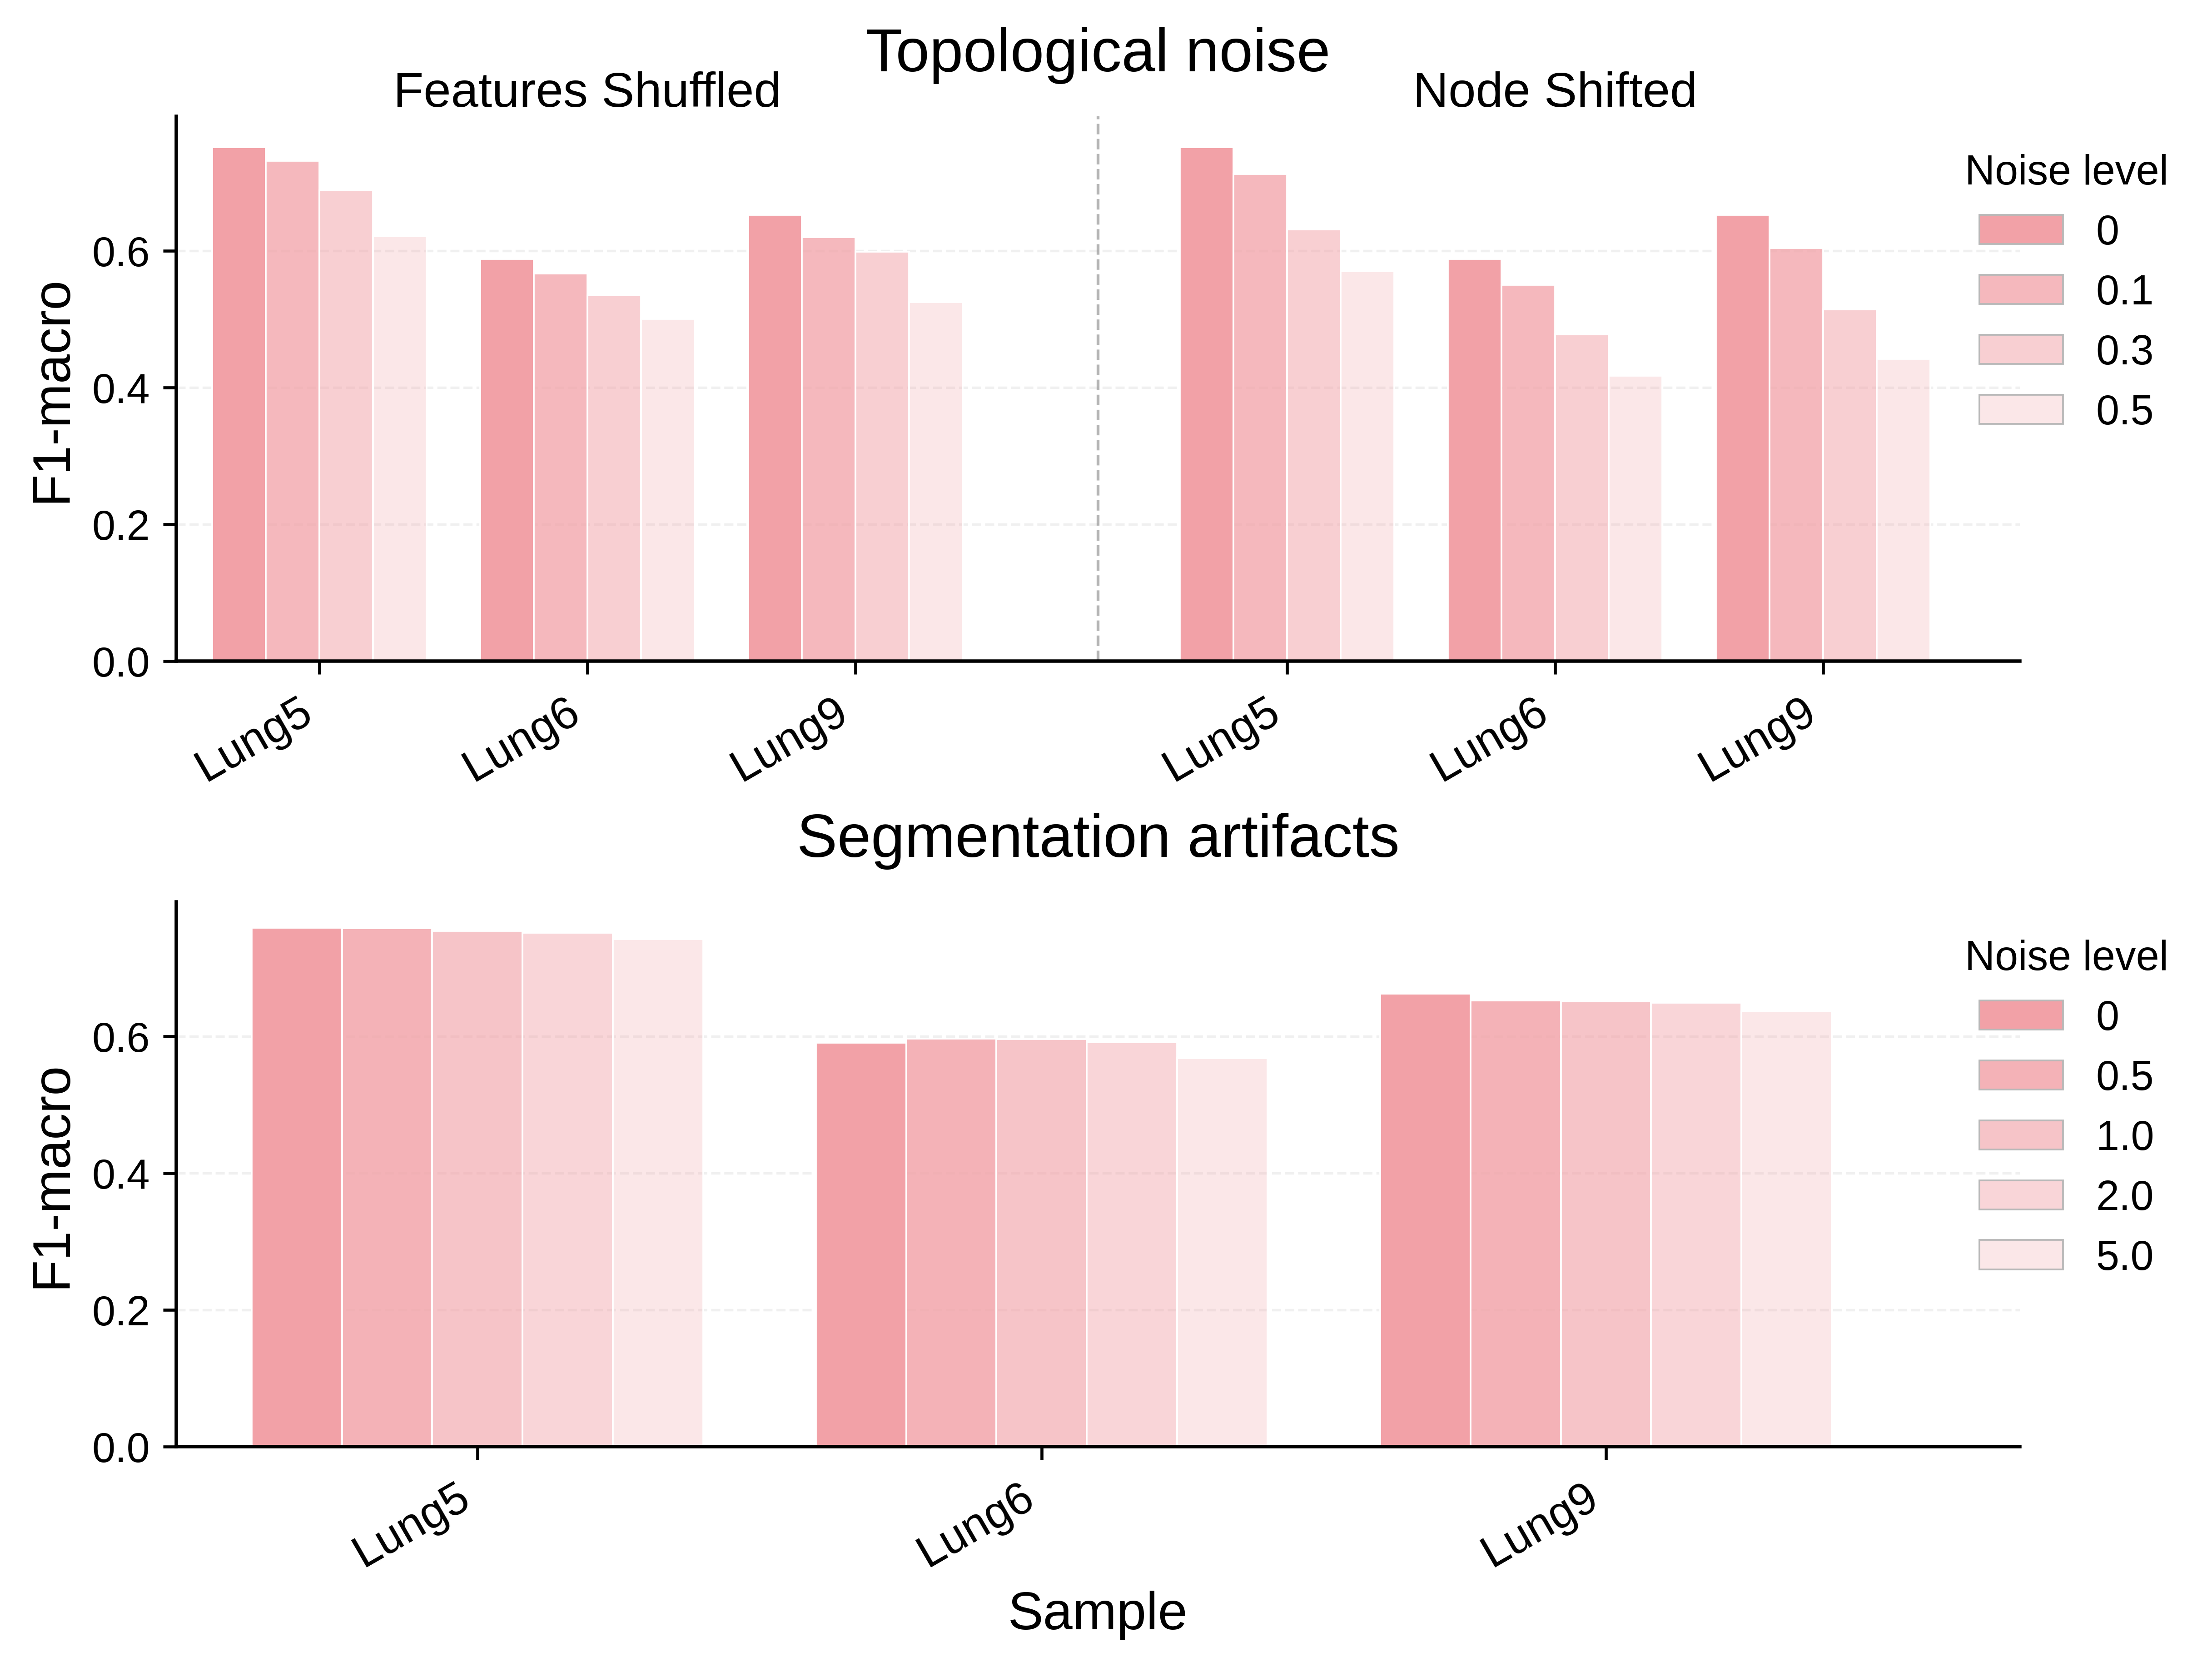

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def unique_preserve(s):
    return pd.Index(s).drop_duplicates().tolist()

def sort_noise_levels(levels):
    levels = list(pd.Index(levels).drop_duplicates())

    def key(x):
        try:
            return (0, float(x))
        except Exception:
            m = re.search(r"[-+]?\d*\.?\d+", str(x))
            if m:
                return (0, float(m.group()))
            return (1, str(x))

    return sorted(levels, key=key)

GRADIENT_BASE_COLOR = "#F2A1A7"
ORDERED_ALPHAS = [1.00, 0.75, 0.50, 0.25]

def alpha_gradient_colors(n_levels):
    if n_levels == len(ORDERED_ALPHAS):
        alphas = ORDERED_ALPHAS
    else:
        alphas = np.linspace(ORDERED_ALPHAS[0], ORDERED_ALPHAS[-1], n_levels)
    return [mcolors.to_rgba(GRADIENT_BASE_COLOR, alpha=float(alpha)) for alpha in alphas]

def plot_blocked_bars(
    ax,
    dfs,
    title,
    ylabel,
    block_labels=None,
    sample_gap=0.18,
    block_gap=0.55,
):
    sample_order = unique_preserve(pd.concat([d["sample"] for d in dfs], ignore_index=True))
    level_order = sort_noise_levels(pd.concat([d["noise_level"] for d in dfs], ignore_index=True))

    n_levels = len(level_order)
    bar_w = 0.72 / n_levels

    # Stable, publication-style mapping
    gradient_colors = alpha_gradient_colors(n_levels)
    level_color = {
        lvl: gradient_colors[i]
        for i, lvl in enumerate(level_order)
    }

    x = 0.0
    xticks, xlabels = [], []
    block_centers = []

    for b, df in enumerate(dfs):
        pivot = (
            df.pivot_table(index="sample", columns="noise_level", values="test", aggfunc="mean")
              .reindex(index=sample_order, columns=level_order)
        )

        block_start = x

        for sample in sample_order:
            cluster_start = x

            for j, lvl in enumerate(level_order):
                val = pivot.loc[sample, lvl]
                if pd.notna(val):
                    ax.bar(
                        cluster_start + j * bar_w,
                        val,
                        width=bar_w,
                        align="edge",
                        color=level_color[lvl],
                        edgecolor="#FFFFFF",
                        linewidth=0.45,
                    )

            xticks.append(cluster_start + (n_levels * bar_w) / 2)
            xlabels.append(str(sample))
            x += n_levels * bar_w + sample_gap

        block_end = x - sample_gap
        block_centers.append((block_start + block_end) / 2)

        if b < len(dfs) - 1:
            ax.axvline(x + block_gap / 2, linestyle="--", linewidth=0.75, color="#8C8C8C", alpha=0.65)
            x += block_gap

    if block_labels is not None:
        for center, label in zip(block_centers, block_labels):
            ax.text(
                center,
                1,
                label,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=13,
                fontweight="regular",
            )

    ax.set_title(title, fontsize=16, pad=12, fontweight="regular")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=12.0)
    ax.tick_params(axis="x", pad=4)
    ax.tick_params(axis="y", labelsize=11)

    ax.grid(axis="y", linestyle="--", linewidth=0.65, alpha=0.18)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_xlim(-0.12, x + 0.12)

    handles = [
        Patch(facecolor=level_color[lvl], edgecolor="#B8B8B8", linewidth=0.45, label=str(lvl))
        for lvl in level_order
    ]
    return handles

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.titleweight": "regular",
})

fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"height_ratios": [1, 1]},
    constrained_layout=True,
    dpi=600
)

handles_top = plot_blocked_bars(
    axes[0],
    dfs=[node_feat_shuffle_df, node_shift_df],
    title="Topological noise",
    ylabel="F1-macro",
    block_labels=["Features Shuffled", "Node Shifted"],
    sample_gap=0.18,
    block_gap=0.55,
)

axes[0].legend(
    handles=handles_top,
    title="Noise level",
    loc="upper left",
    frameon=False,
    bbox_to_anchor=(0.95, 1),
)

handles_seg = plot_blocked_bars(
    axes[1],
    dfs=[segmentation_noise_df],
    title="Segmentation artifacts",
    ylabel="F1-macro",
    sample_gap=0.18,
    block_gap=0.55,
)

axes[1].legend(
    handles=handles_seg,
    title="Noise level",
    loc="upper left",
    frameon=False,
    bbox_to_anchor=(0.95, 1),
)

axes[1].set_xlabel("Sample", fontsize=14)

output_dir = '/fs/ess/PAS1475/yzhong/sf_project/scripts/benchmark_results/05_19_26'
fig.savefig(f'{output_dir}/013_noise_view_datasets_polished_07_17.pdf', bbox_inches='tight')
fig.savefig(f'{output_dir}/013_noise_view_datasets_polished_07_17.png', dpi=600, bbox_inches='tight')

plt.show()